(200, 2) (200,)


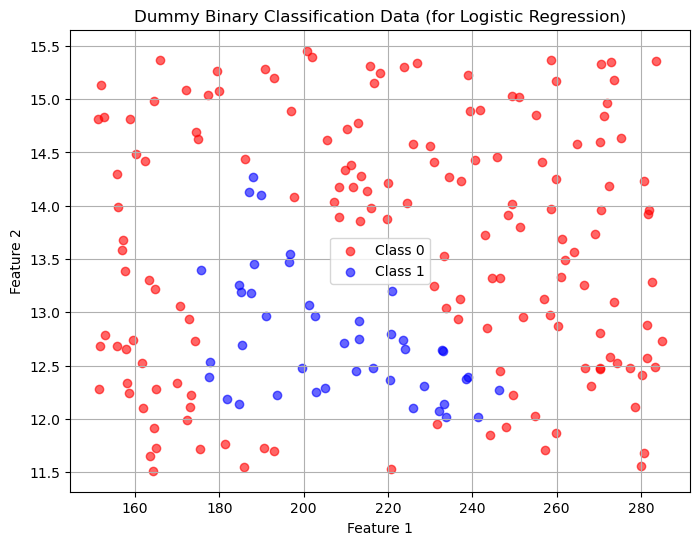

In [2]:
import numpy as np
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y)

X,y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()



In [12]:
normal_data = X[y==1]
mu = np.mean(normal_data,axis = 0)
sigma = np.std(normal_data,axis = 0)
px = (1/((np.sqrt(2*np.pi))*sigma))*np.exp((-np.square(normal_data-mu))/(2*np.square(sigma)))
p_n = np.prod(px, axis=1)
# p = []

best_epsilon=0
best_f1=0
epsilon = 0
for eps in np.linspace(min(p_n),max(p_n),10):
    px = (1/((np.sqrt(2*np.pi))*sigma))*np.exp((-np.square(X-mu))/(2*np.square(sigma)))
    p = np.prod(px, axis=1)
    pred = ~(p<eps)
    
    TP = np.sum((y == 1) & (pred == 1))
    FP = np.sum((y == 0) & (pred == 1))
    FN = np.sum((y == 1) & (pred == 0))
    
    precision = TP / (TP + FP+1e-8)
    recall = TP / (TP + FN+1e-8)
    f1 = 2 * precision * recall / (precision + recall+1e-8)
    

    if f1 > best_f1:
        best_f1 = f1
        best_epsilon = eps

    
    
    
px = (1/((np.sqrt(2*np.pi))*sigma))*np.exp((-np.square(X-mu))/(2*np.square(sigma)))
p = np.prod(px, axis=1)
pred = ~(p < best_epsilon)
np.mean(pred==y)*100

np.float64(94.0)

np.float64(94.0)

In [25]:
best_epsilon,best_f1

(np.float64(8.852543370958785e-05), np.float64(0.8757062097036292))

In [26]:
epsilon


0

In [27]:
print(precision)

0.7868020304169135


In [28]:
print(recall)

0.9872611464339324


In [29]:
print(f1)

0.8757062097036292


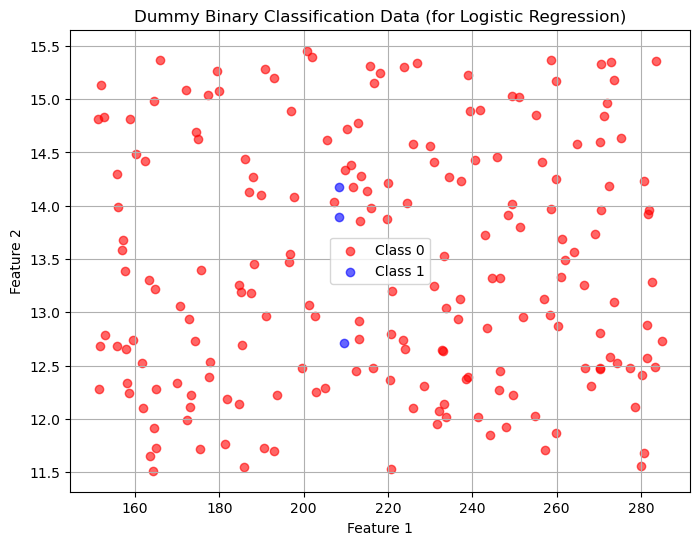

In [30]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[pred.flatten() == 0][:, 0], X[pred.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[pred.flatten() == 1][:, 0], X[pred.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()